**Cell 1 — Imports and configuration**

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import genextreme, genpareto

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")

N_TAIL = 100

**Cell 2 — Load and combine returns**

In [44]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

print(f"Data shape: {returns.shape}")
print(f"Sample date range: {returns.index.min().date()} to {returns.index.max().date()}")

Data shape: (7522, 3)
Sample date range: 1996-12-17 to 2026-05-04


**Cell 3 — Equal-weighted portfolio negative log-returns**

In [45]:
b = np.array([1, 1, 1]) / 3
x_full = -(returns @ b).values

n = len(x_full)              # fixed: full series length
x_sorted = np.sort(x_full)[::-1]
m = min(N_TAIL, n)
x = x_sorted[:m]              # fixed: slice the sorted array

**Cell 4 — Tail index regression**

In [46]:
X_design = np.column_stack([np.ones(m), x])
y1 = np.log(np.arange(1, m + 1) / n)

g = np.linalg.solve(X_design.T @ X_design, X_design.T @ y1)

line = g[0] + g[1] * x
alpha = -g[1]
gamma = 1 / alpha

**Cell 5 — Plot, display and save**

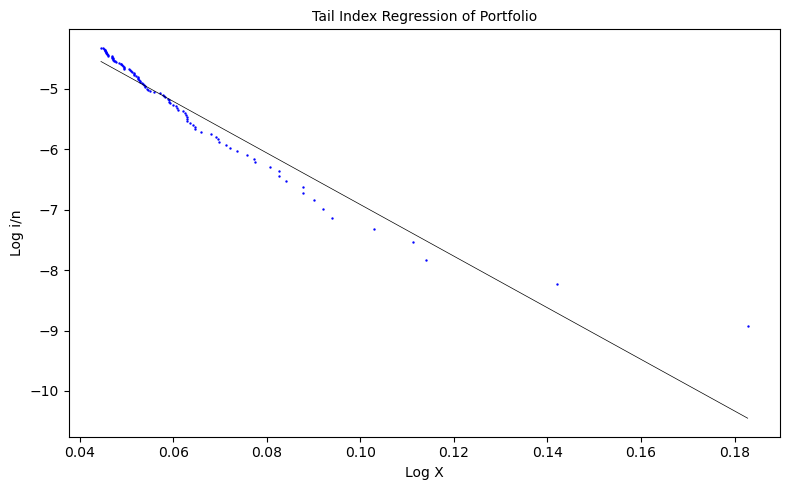

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, line, color="black", linewidth=0.5, label="Regression line")
ax.scatter(x, y1, color="blue", s=0.5, label="Observed log(i/n)")

ax.set_xlabel("Log X")
ax.set_ylabel("Log i/n")
ax.set_title(
    "Tail Index Regression of Portfolio",
    fontsize=10
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tail_index_regression.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()

**Cell 6 — ANOVA table**

In [48]:
# ── ANOVA on the tail index regression (continues from previous cell) ──
# Assumes x, y1, g, line, m, n already exist from the regression block

y_mean = np.mean(y1)

SS_total   = np.sum((y1 - y_mean) ** 2)          # SST
SS_columns = np.sum((line - y_mean) ** 2)        # SSR (explained by regression)
SS_error   = np.sum((y1 - line) ** 2)            # SSE (residuals)

df_columns = 1              # one predictor (x)
df_error   = m - 2          # m observations minus 2 parameters (intercept, slope)
df_total   = m - 1

MS_columns = SS_columns / df_columns
MS_error   = SS_error / df_error

F_stat  = MS_columns / MS_error
p_value = 1 - stats.f.cdf(F_stat, df_columns, df_error)
r_squared = SS_columns / SS_total

print("=" * 60)
print(f"{'ANOVA Table':^60}")
print("=" * 60)
print(f"{'Source':<12} {'SS':>10} {'df':>6} {'MS':>10} {'F':>10} {'Prob > F':>10}")
print("-" * 60)
print(f"{'Columns':<12} {SS_columns:>10.3f} {df_columns:>6} {MS_columns:>10.3f} {F_stat:>10.2f} {p_value:>10.4f}")
print(f"{'Error':<12} {SS_error:>10.3f} {df_error:>6} {MS_error:>10.3f}")
print(f"{'Total':<12} {SS_total:>10.3f} {df_total:>6}")
print("=" * 60)
print(f"\nR-squared = {r_squared:.4f}")
print(f"Tail index alpha = {alpha:.4f}")
print(f"Extreme value index gamma = 1/alpha = {gamma:.4f}")

                        ANOVA Table                         
Source               SS     df         MS          F   Prob > F
------------------------------------------------------------
Columns          79.667      1     79.667    1394.09     0.0000
Error             5.600     98      0.057
Total            85.267     99

R-squared = 0.9343
Tail index alpha = 42.7126
Extreme value index gamma = 1/alpha = 0.0234


**Cell 7 - Block Maxima: fit GEV**

In [49]:
block_size = n // m
n_blocks = n // block_size
block_max = np.array([
    x_full[i * block_size:(i + 1) * block_size].max()
    for i in range(n_blocks)
])

c_bm, loc_bm, scale_bm = genextreme.fit(block_max)
gamma_block_max = -c_bm  # scipy genextreme: c = -xi, sign flip required

**Cell 8 — POT: fit GPD**

In [50]:
threshold = x_sorted[m]
exceedances = x_full[x_full > threshold] - threshold

c_pot, loc_pot, scale_pot = genpareto.fit(exceedances, floc=0)
gamma_pot = c_pot  # genpareto: c = xi directly, no flip needed

**Cell 9 — Hill estimator**

In [51]:
log_diffs = np.log(x_sorted[:m]) - np.log(x_sorted[m])
gamma_hill = np.mean(log_diffs)

**Cell 10 — Shape Parameter table**

In [52]:
shape_df = pd.DataFrame({
    "gamma_hat": [gamma_block_max, gamma_pot, gamma, gamma_hill]
}, index=["Block Max", "POT", "Regression", "Hill"])

print(shape_df.round(4))

            gamma_hat
Block Max      0.2564
POT            0.1561
Regression     0.0234
Hill           0.2921
